# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
from ucimlrepo import fetch_ucirepo


warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

# Load Data

In [2]:
diabetes = fetch_ucirepo(id= 296)

X_raw = diabetes.data.features.copy()
y_raw = diabetes.data.targets.copy()

In [3]:
df = pd.concat([X_raw, y_raw], axis= 1)
print(f"Shape of the dataset: {df.shape}")
df.head()

Shape of the dataset: (101766, 48)


,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [73]:
# readmitted: '<30' → 1 (high risk), '>30' or 'NO' → 0
df['readmitted_30d'] = (df['readmitted'] == '<30').astype(int)
print(df['readmitted'].value_counts())
print(f"\nTarget distribution:\n{df['readmitted_30d'].value_counts(normalize=True).round(3)}")

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Target distribution:
readmitted_30d
0    0.888
1    0.112
Name: proportion, dtype: float64


In [74]:
print(df.dtypes)

race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride                 object
acetohexamide               object
glipizide           

In [75]:
print(f'Null counts in each column:\n{df.isnull().sum()[df.isnull().sum() > 0]}')

Null counts in each column:
race                  2273
weight               98569
payer_code           40256
medical_specialty    49949
diag_1                  21
diag_2                 358
diag_3                1423
max_glu_serum        96420
A1Cresult            84748
dtype: int64


# EXPLORATORY DATA ANALYSIS

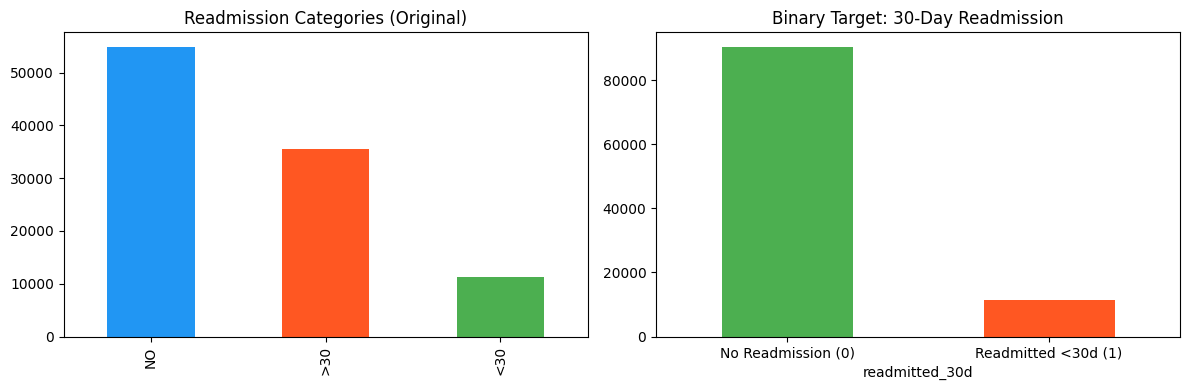

In [76]:
# Target Distribution

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['readmitted'].value_counts().plot(kind='bar', ax=axes[0], color=['#2196F3','#FF5722','#4CAF50'])
axes[0].set_title('Readmission Categories (Original)')
axes[0].set_xlabel('')

df['readmitted_30d'].value_counts().plot(kind='bar', ax=axes[1], color=['#4CAF50','#FF5722'])
axes[1].set_title('Binary Target: 30-Day Readmission')
axes[1].set_xticklabels(['No Readmission (0)', 'Readmitted <30d (1)'], rotation=0)

plt.tight_layout()
plt.show()

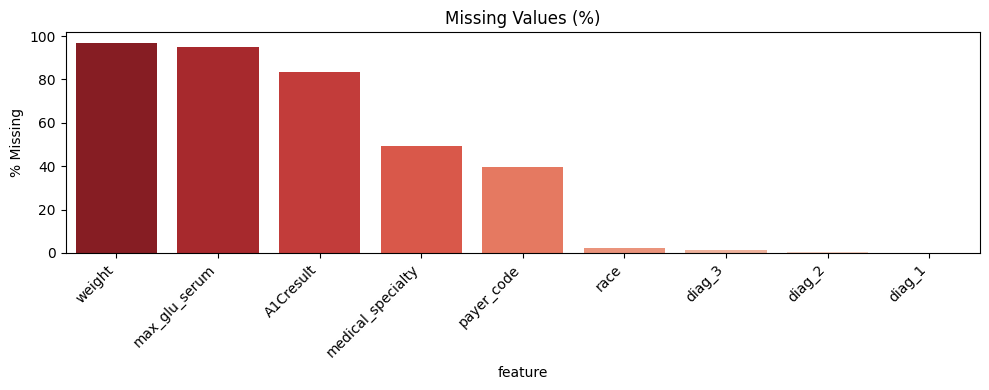

In [77]:
# Missing Values Heatmap

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).sort_values(ascending=False)
missing_df = missing_pct[missing_pct > 0].reset_index()
missing_df.columns = ['feature', 'missing_pct']

plt.figure(figsize=(10, 4))
sns.barplot(data=missing_df, x='feature', y='missing_pct', palette='Reds_r')
plt.xticks(rotation=45, ha='right')
plt.title('Missing Values (%)')
plt.ylabel('% Missing')
plt.tight_layout()
plt.show()

Numerical columns: ['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']


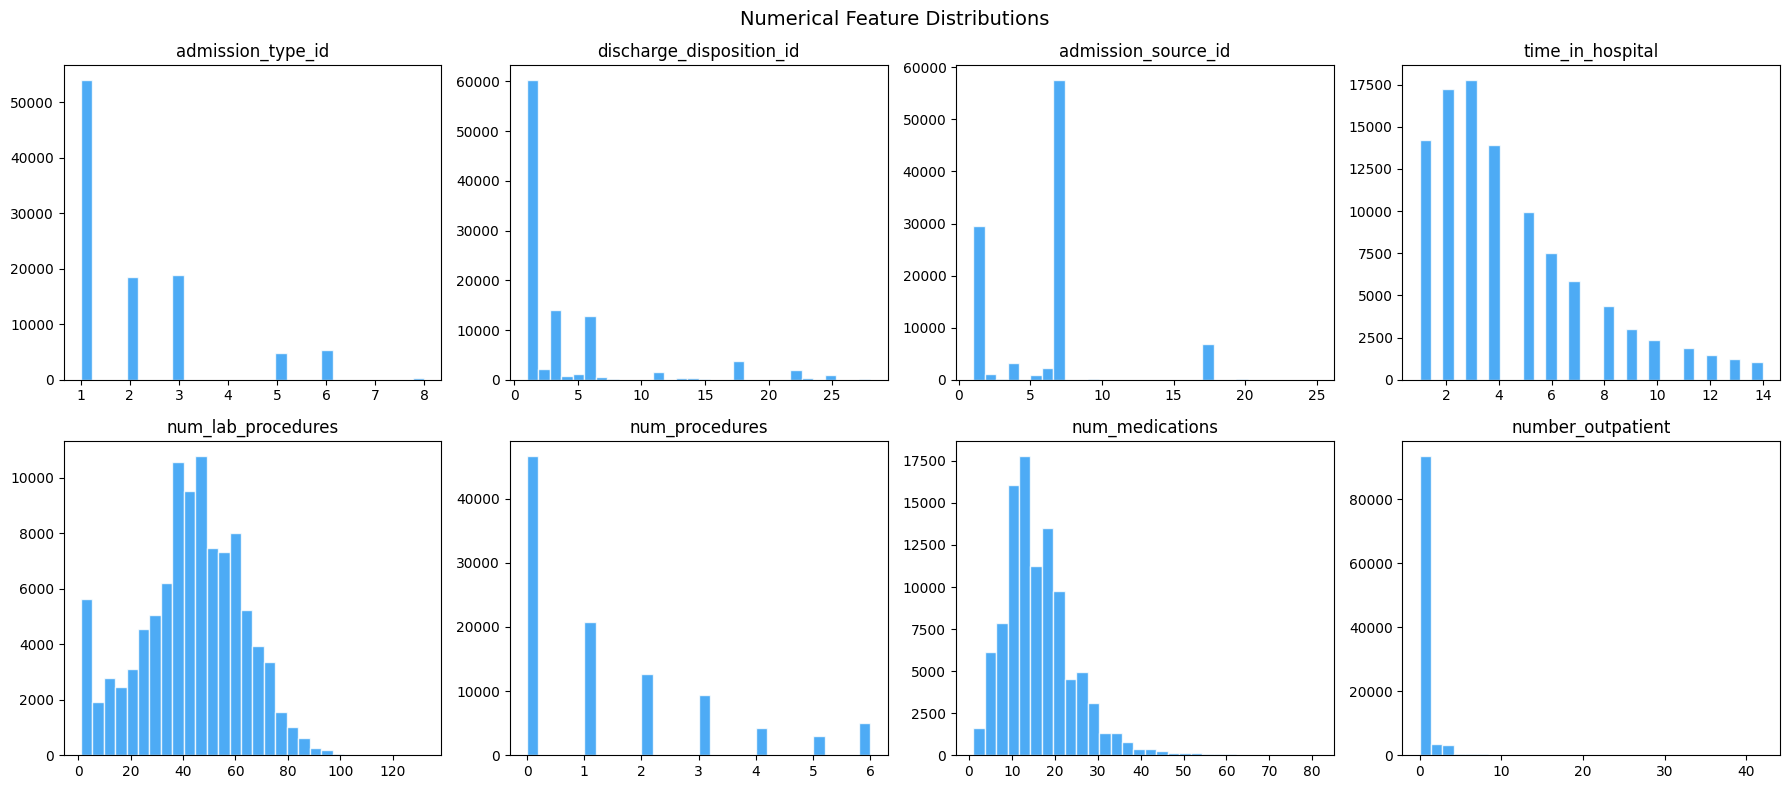

In [78]:
# Numerical Feature Distributions

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ['readmitted_30d', 'encounter_id', 'patient_nbr']]
print(f"Numerical columns: {num_cols}")

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols[:8]):
    axes[i].hist(df[col].dropna(), bins=30, color='#2196F3', edgecolor='white', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
plt.suptitle('Numerical Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

In [79]:
# Categorical Feature Value Counts
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c != 'readmitted']
print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")

# Cardinality check
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values → {df[col].value_counts().head(3).to_dict()}")


Categorical columns (36): ['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']
race: 5 unique values → {'Caucasian': 76099, 'AfricanAmerican': 19210, 'Hispanic': 2037}
gender: 3 unique values → {'Female': 54708, 'Male': 47055, 'Unknown/Invalid': 3}
age: 10 unique values → {'[70-80)': 26068, '[60-70)': 22483, '[50-60)': 17256}
weight: 9 unique values → {'[75-100)': 1336, '[50-75)': 897, '[100-125)': 625}
payer_code: 17 unique values → {'MC': 32439, 'HM': 6274, 'SP': 5007}
medical_specialty: 72 unique values 

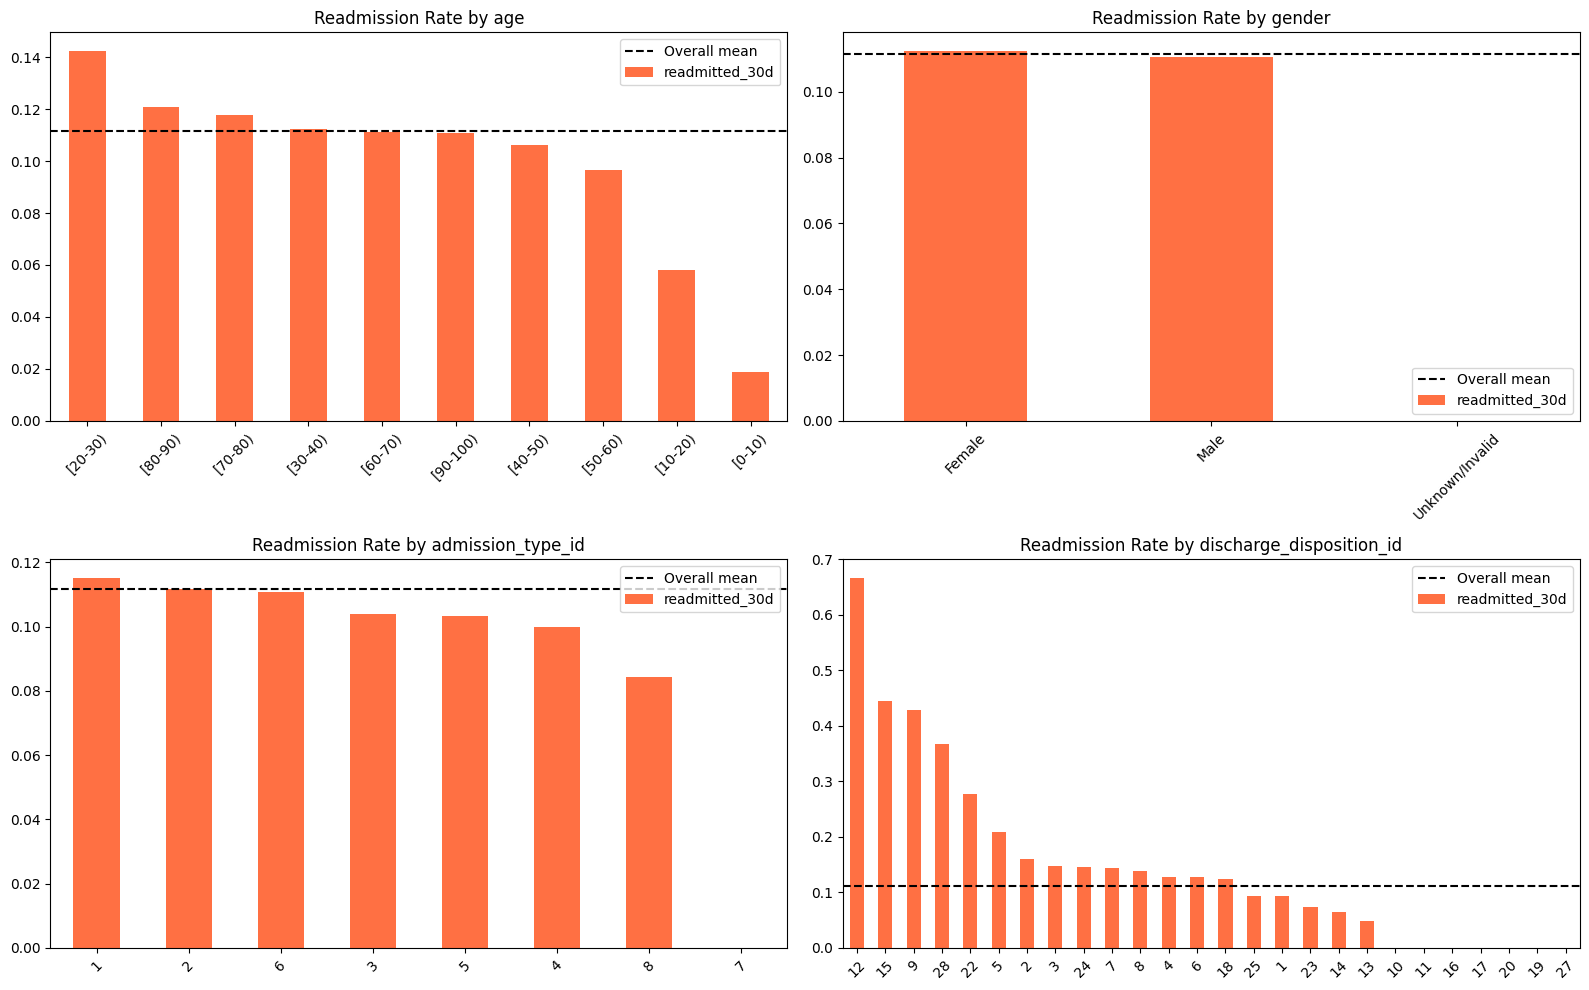

In [80]:
# Readmission Rate by Key Categorical Features
key_cats = ['age', 'gender', 'admission_type_id', 'discharge_disposition_id']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(key_cats):
    rate = df.groupby(col)['readmitted_30d'].mean().sort_values(ascending=False)
    rate.plot(kind='bar', ax=axes[i], color='#FF5722', alpha=0.85)
    axes[i].set_title(f'Readmission Rate by {col}')
    axes[i].set_xlabel('')
    axes[i].axhline(df['readmitted_30d'].mean(), color='black', linestyle='--', label='Overall mean')
    axes[i].legend()
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

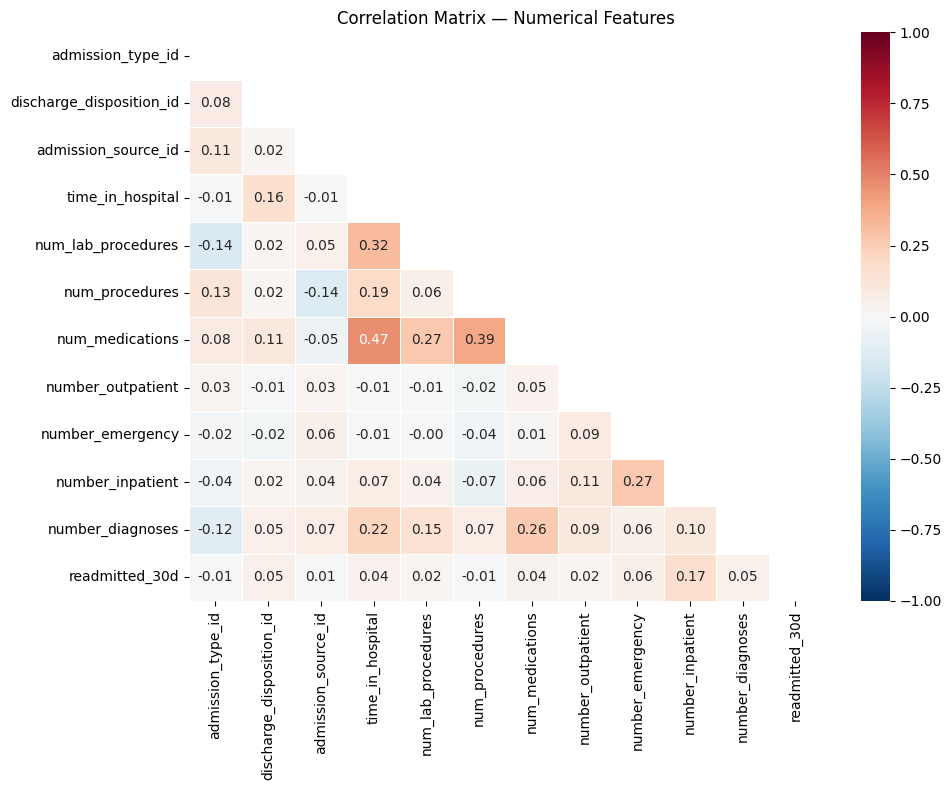

In [81]:
# Correlation Matrix (Numerical)
corr_cols = num_cols + ['readmitted_30d']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5)
plt.title('Correlation Matrix — Numerical Features')
plt.tight_layout()
plt.show()

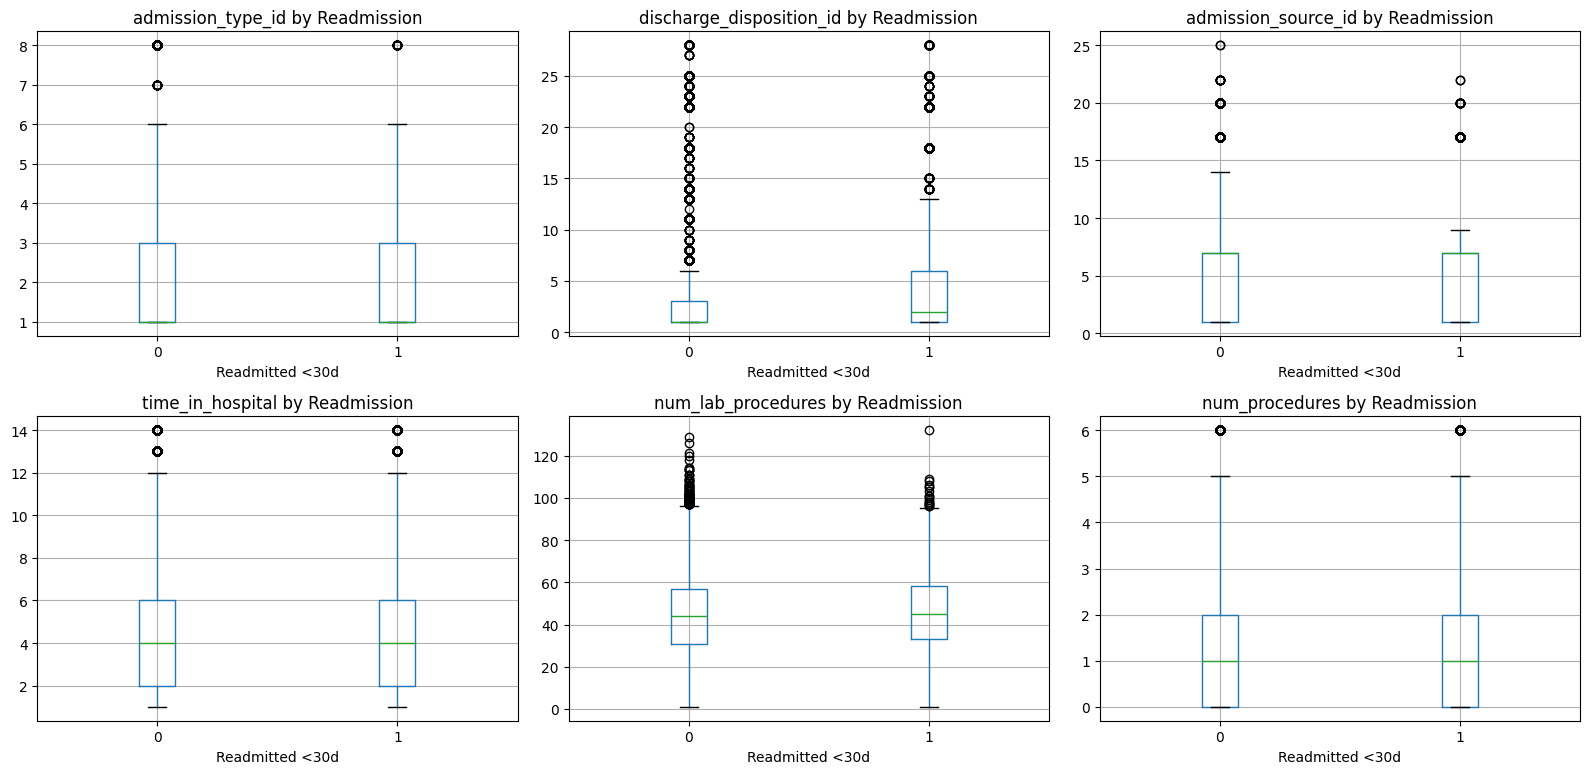

In [82]:
# Readmission vs Numerical Features
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols[:6]):
    df.boxplot(column=col, by='readmitted_30d', ax=axes[i])
    axes[i].set_title(f'{col} by Readmission')
    axes[i].set_xlabel('Readmitted <30d')

plt.suptitle('')
plt.tight_layout()
plt.show()

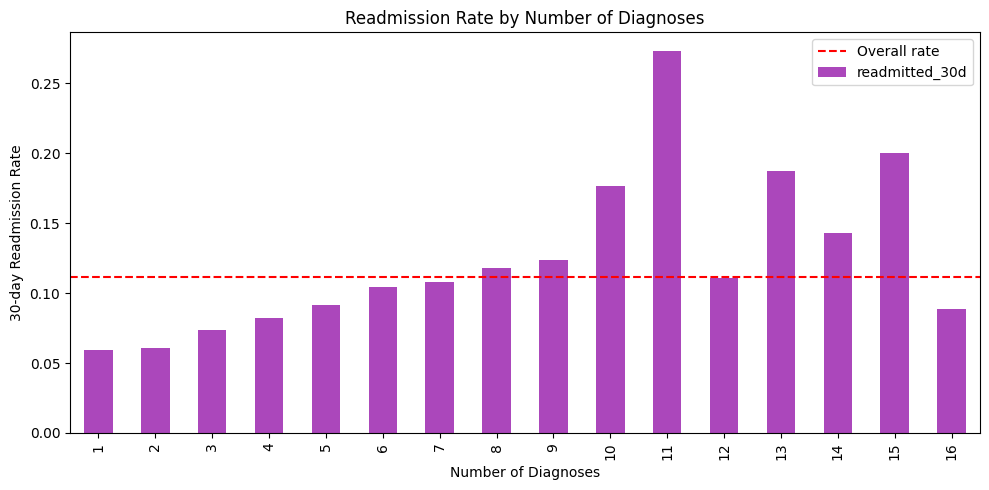

In [83]:
# Number of Diagnoses vs Readmission
plt.figure(figsize=(10, 5))
df.groupby('number_diagnoses')['readmitted_30d'].mean().plot(
    kind='bar', color='#9C27B0', alpha=0.85
)
plt.axhline(df['readmitted_30d'].mean(), color='red', linestyle='--', label='Overall rate')
plt.xlabel('Number of Diagnoses')
plt.ylabel('30-day Readmission Rate')
plt.title('Readmission Rate by Number of Diagnoses')
plt.legend()
plt.tight_layout()
plt.show()

# DATA PREPROCESSING

In [84]:
drop_cols = [
    'encounter_id',       # ID — no signal
    'patient_nbr',        # ID — no signal
    'readmitted',         # original target — keep binary version only
    'examide',            # near-zero variance
    'citoglipton',        # near-zero variance
]
df = df.drop(columns=drop_cols, errors='ignore')
print(f"Shape after dropping: {df.shape}")

Shape after dropping: (101766, 46)


In [85]:
df = df.replace('?', np.nan)

In [86]:
missing_after = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print("Missing % after '?' replacement:")
print(missing_after[missing_after > 0])

Missing % after '?' replacement:
weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
dtype: float64


In [87]:
HIGH_MISSING_THRESHOLD = 35.0
high_missing = missing_after[missing_after > HIGH_MISSING_THRESHOLD].index.tolist()
print(f"Dropping high-missing columns (>{HIGH_MISSING_THRESHOLD}%): {high_missing}")
df = df.drop(columns=high_missing)

Dropping high-missing columns (>35.0%): ['weight', 'max_glu_serum', 'A1Cresult', 'medical_specialty', 'payer_code']


In [88]:
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
age_map = {bracket: i for i, bracket in enumerate(age_order)}
df['age_numeric'] = df['age'].map(age_map)

In [89]:
# Clinical risk buckets: 0-30 (low), 30-60 (medium), 60+ (high)
def age_to_risk_bucket(age_bracket):
    if pd.isna(age_bracket):
        return 'Unknown'
    idx = age_map.get(age_bracket, 0)
    if idx <= 2:   return 'Young'
    elif idx <= 5: return 'Middle'
    else:          return 'Elderly'

df['age_risk_bucket'] = df['age'].apply(age_to_risk_bucket)
print(df['age_risk_bucket'].value_counts())

age_risk_bucket
Elderly    68541
Middle     30716
Young       2509
Name: count, dtype: int64


In [90]:
# Medication columns: 'No' or 'Steady'/'Up'/'Down' 
med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
            'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
            'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
            'miglitol', 'troglitazone', 'tolazamide', 'insulin',
            'glyburide-metformin', 'glipizide-metformin',
            'glimepiride-pioglitazone', 'metformin-rosiglitazone',
            'metformin-pioglitazone']

# Keep only med_cols that exist in df
med_cols = [c for c in med_cols if c in df.columns]
print(f"Med columns found: {len(med_cols)}")

Med columns found: 21


In [91]:
# Count active medications (not 'No')
def med_active(val):
    if pd.isna(val): return 0
    return 0 if val == 'No' else 1

df['n_active_medications'] = df[med_cols].applymap(med_active).sum(axis=1)
df['any_insulin'] = (df['insulin'].isin(['Up', 'Down', 'Steady'])).astype(int)
df['insulin_increased'] = (df['insulin'] == 'Up').astype(int)

In [92]:
# ICD-10 Diagnosis Category

def icd_to_category(code):
    if pd.isna(code) or code in ['?', 'E', 'V']:
        return 'Other'
    try:
        code_str = str(code)
        if code_str.startswith('V') or code_str.startswith('E'):
            return 'External'
        num = float(code_str.split('.')[0])
        if 1 <= num <= 139:    return 'Infectious'
        elif 140 <= num <= 239: return 'Neoplasms'
        elif 240 <= num <= 279: return 'Endocrine'   # Diabetes lives here
        elif 280 <= num <= 289: return 'Blood'
        elif 290 <= num <= 319: return 'Mental'
        elif 320 <= num <= 389: return 'Nervous'
        elif 390 <= num <= 459: return 'Circulatory'
        elif 460 <= num <= 519: return 'Respiratory'
        elif 520 <= num <= 579: return 'Digestive'
        elif 580 <= num <= 629: return 'Genitourinary'
        elif 630 <= num <= 679: return 'Pregnancy'
        elif 680 <= num <= 709: return 'Skin'
        elif 710 <= num <= 739: return 'Musculoskeletal'
        elif 740 <= num <= 759: return 'Congenital'
        elif 780 <= num <= 799: return 'Symptoms'
        elif 800 <= num <= 999: return 'Injury'
        else: return 'Other'
    except:
        return 'Other'

for diag_col in ['diag_1', 'diag_2', 'diag_3']:
    if diag_col in df.columns:
        df[f'{diag_col}_category'] = df[diag_col].apply(icd_to_category)

print(df['diag_1_category'].value_counts())

diag_1_category
Circulatory        30336
Endocrine          11459
Respiratory        10407
Digestive           9208
Symptoms            7636
Injury              6974
Genitourinary       5078
Musculoskeletal     4957
Neoplasms           3433
Infectious          2768
Skin                2530
Mental              2262
External            1645
Nervous             1211
Blood               1103
Pregnancy            687
Congenital            51
Other                 21
Name: count, dtype: int64


In [93]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

# Encode gender
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1, 'Unknown/Invalid': -1})
df['gender'] = df['gender'].fillna(-1)

In [94]:
# High-cardinality: drop raw diag columns (we have categories now)
df = df.drop(columns=['diag_1', 'diag_2', 'diag_3'], errors='ignore')

In [95]:
# Encode change, diabetesMed
if 'change' in df.columns:
    df['change'] = (df['change'] == 'Ch').astype(int)
if 'diabetesMed' in df.columns:
    df['diabetesMed'] = (df['diabetesMed'] == 'Yes').astype(int)

In [96]:
# Fill remaining nulls in numerical columns
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())

print(f"Shape after preprocessing: {df.shape}")
print(f"Remaining nulls: {df.isnull().sum().sum()}")

Shape after preprocessing: (101766, 46)
Remaining nulls: 2273


# FEATURE ENGINEERING

In [97]:
# Clinical domain interactions
df['age_x_ndiagnoses'] = df['age_numeric'] * df['number_diagnoses']
df['n_meds_x_ndiagnoses'] = df['n_active_medications'] * df['number_diagnoses']
df['inpatient_x_emergency'] = (
    df['number_inpatient'] * df['number_emergency']
    if 'number_inpatient' in df.columns and 'number_emergency' in df.columns
    else 0
)

In [98]:
# Prior visit count (total utilization signal)
visit_cols = ['number_outpatient', 'number_emergency', 'number_inpatient']
visit_cols = [c for c in visit_cols if c in df.columns]
df['total_prior_visits'] = df[visit_cols].sum(axis=1)
df['has_prior_inpatient'] = (df['number_inpatient'] > 0).astype(int) if 'number_inpatient' in df.columns else 0

In [99]:
# High-utilizer flag
df['high_utilizer'] = (df['total_prior_visits'] > df['total_prior_visits'].quantile(0.75)).astype(int)

print("Interaction features added.")
print(f"Final shape: {df.shape}")

Interaction features added.
Final shape: (101766, 52)


In [100]:
# The dataset has multiple encounters per patient.
# Strategy: keep first encounter per patient (to avoid leakage)
# Note: patient_nbr was already dropped — 
# if you kept it, de-duplicate here. We proceed as-is.
print(f"Total records: {len(df)}")

Total records: 101766


In [102]:
df.dropna(inplace=True)
print(f"Records after dropping nulls: {len(df)}")

Records after dropping nulls: 99493


# FEATURE SELECTION

In [103]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [104]:
TARGET = 'readmitted_30d'
y = df[TARGET]
X = df.drop(columns=[TARGET, 'age'], errors='ignore')  # drop raw age (we have numeric + bucket)

In [105]:
# Identify column types
cat_cols_final = X.select_dtypes(include=['object']).columns.tolist()
num_cols_final = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"Categorical: {len(cat_cols_final)} → {cat_cols_final}")
print(f"Numerical: {len(num_cols_final)}")

Categorical: 26 → ['race', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'age_risk_bucket', 'diag_1_category', 'diag_2_category', 'diag_3_category']
Numerical: 24


In [106]:
# Encode categoricals for feature selection
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_cat_enc = enc.fit_transform(X[cat_cols_final]) if cat_cols_final else np.empty((len(X), 0))
X_num = X[num_cols_final].values
X_all = np.hstack([X_num, X_cat_enc])
feature_names = num_cols_final + cat_cols_final

print(f"Feature matrix shape: {X_all.shape}")

Feature matrix shape: (99493, 50)


In [107]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X_all, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)

In [108]:
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Train positive rate: {y_train.mean():.3f}")
print(f"Val positive rate:   {y_val.mean():.3f}")
print(f"Test positive rate:  {y_test.mean():.3f}")

Train: (69684, 50), Val: (14885, 50), Test: (14924, 50)
Train positive rate: 0.112
Val positive rate:   0.112
Test positive rate:  0.112


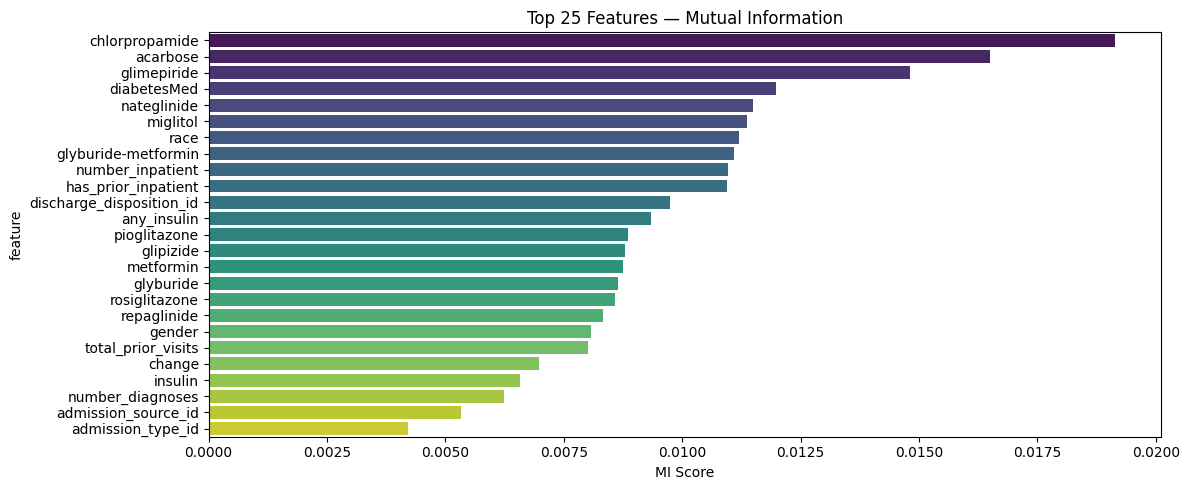

In [109]:
# Filter Feature Selection — Mutual Information

from sklearn.feature_selection import mutual_info_classif, SelectKBest, f_classif

mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
mi_df = pd.DataFrame({'feature': feature_names, 'mi_score': mi_scores})
mi_df = mi_df.sort_values('mi_score', ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(data=mi_df.head(25), x='mi_score', y='feature', palette='viridis')
plt.title('Top 25 Features — Mutual Information')
plt.xlabel('MI Score')
plt.tight_layout()
plt.show()

In [110]:
# Embedded Selection — LASSO / L1

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, max_iter=500)
lasso.fit(X_train_scaled, y_train)

lasso_coefs = pd.DataFrame({'feature': feature_names, 'coef': np.abs(lasso.coef_[0])})
lasso_coefs = lasso_coefs.sort_values('coef', ascending=False)

selected_lasso = lasso_coefs[lasso_coefs['coef'] > 0]['feature'].tolist()
print(f"LASSO selected {len(selected_lasso)} features")

LASSO selected 42 features


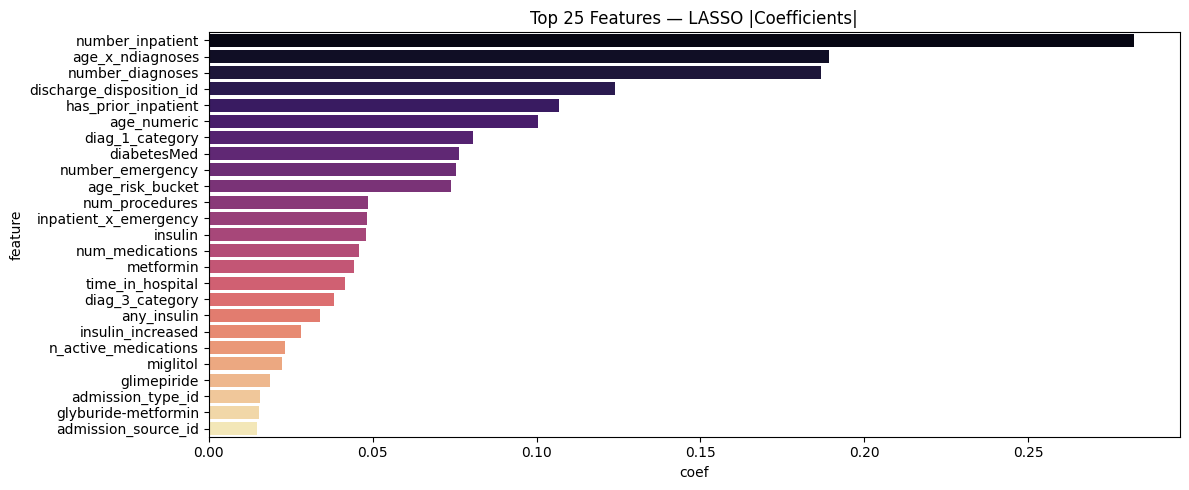

In [111]:
plt.figure(figsize=(12, 5))
sns.barplot(data=lasso_coefs.head(25), x='coef', y='feature', palette='magma')
plt.title('Top 25 Features — LASSO |Coefficients|')
plt.tight_layout()
plt.show()

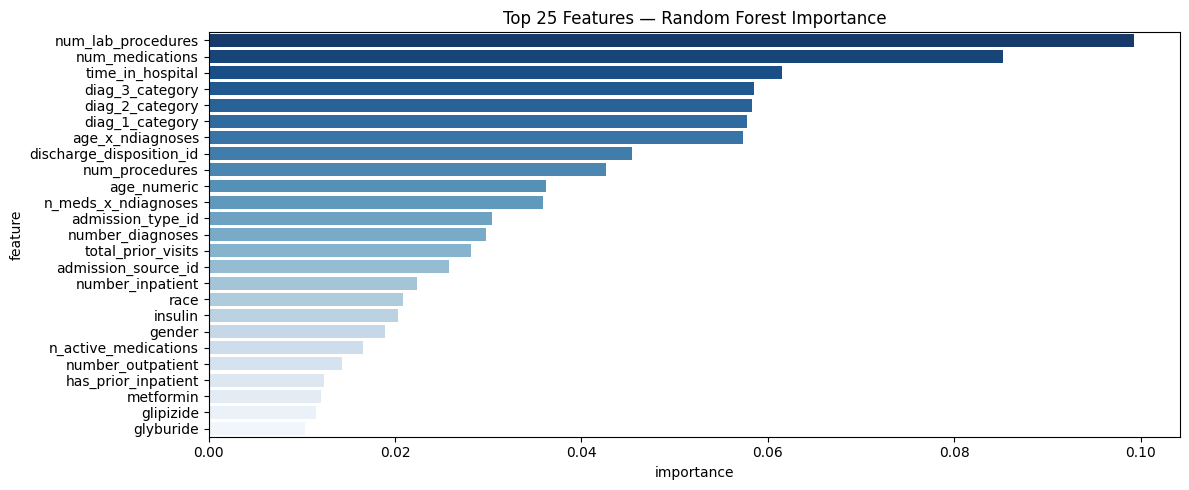

In [112]:
# Tree-based Importance

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
rf.fit(X_train, y_train)

rf_importance = pd.DataFrame({'feature': feature_names, 'importance': rf.feature_importances_})
rf_importance = rf_importance.sort_values('importance', ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(data=rf_importance.head(25), x='importance', y='feature', palette='Blues_r')
plt.title('Top 25 Features — Random Forest Importance')
plt.tight_layout()
plt.show()

In [113]:
# Consensus Feature Selection

top_k = 30

top_mi = set(mi_df.head(top_k)['feature'].tolist())
top_lasso = set(lasso_coefs.head(top_k)['feature'].tolist())
top_rf = set(rf_importance.head(top_k)['feature'].tolist())

consensus = top_mi & top_lasso & top_rf
in_two = (top_mi & top_lasso) | (top_mi & top_rf) | (top_lasso & top_rf)

print(f"In all 3 methods: {len(consensus)} features → {consensus}")
print(f"In at least 2 methods: {len(in_two)} features")

In all 3 methods: 13 features → {'admission_type_id', 'number_inpatient', 'age_numeric', 'admission_source_id', 'insulin', 'has_prior_inpatient', 'number_diagnoses', 'discharge_disposition_id', 'inpatient_x_emergency', 'n_active_medications', 'time_in_hospital', 'any_insulin', 'metformin'}
In at least 2 methods: 34 features


In [114]:
# Use union of top-K across methods as final feature set
final_features = list(top_mi | top_lasso | top_rf)
print(f"Final feature set: {len(final_features)} features")

Final feature set: 43 features


In [115]:
# Get indices for final features
feat_idx = [feature_names.index(f) for f in final_features]
X_train_sel = X_train[:, feat_idx]
X_val_sel   = X_val[:, feat_idx]
X_test_sel  = X_test[:, feat_idx]

# MODEL TRAINING

In [116]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

lr = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)
lr.fit(X_train_sel, y_train)

lr_val_preds = lr.predict_proba(X_val_sel)[:, 1]
print(f"[Baseline LR] Val AUC-ROC: {roc_auc_score(y_val, lr_val_preds):.4f}")
print(f"[Baseline LR] Val AUC-PR:  {average_precision_score(y_val, lr_val_preds):.4f}")

[Baseline LR] Val AUC-ROC: 0.6493
[Baseline LR] Val AUC-PR:  0.1949


In [117]:
import xgboost as xgb

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos:.2f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric='aucpr',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_sel, y_train,
    eval_set=[(X_val_sel, y_val)],
    verbose=50
)

xgb_val_preds = xgb_model.predict_proba(X_val_sel)[:, 1]
print(f"\n[XGBoost Default] Val AUC-ROC: {roc_auc_score(y_val, xgb_val_preds):.4f}")
print(f"[XGBoost Default] Val AUC-PR:  {average_precision_score(y_val, xgb_val_preds):.4f}")


scale_pos_weight: 7.91
[0]	validation_0-aucpr:0.20662
[50]	validation_0-aucpr:0.21917
[100]	validation_0-aucpr:0.22158
[150]	validation_0-aucpr:0.22274
[200]	validation_0-aucpr:0.22230
[250]	validation_0-aucpr:0.22194
[299]	validation_0-aucpr:0.22132

[XGBoost Default] Val AUC-ROC: 0.6764
[XGBoost Default] Val AUC-PR:  0.2219


In [118]:
import lightgbm as lgb

lgbm_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_model.fit(
    X_train_sel, y_train,
    eval_set=[(X_val_sel, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)

lgbm_val_preds = lgbm_model.predict_proba(X_val_sel)[:, 1]
print(f"\n[LightGBM Default] Val AUC-ROC: {roc_auc_score(y_val, lgbm_val_preds):.4f}")
print(f"[LightGBM Default] Val AUC-PR:  {average_precision_score(y_val, lgbm_val_preds):.4f}")

[100]	valid_0's binary_logloss: 0.628882
[200]	valid_0's binary_logloss: 0.618124
[300]	valid_0's binary_logloss: 0.608988

[LightGBM Default] Val AUC-ROC: 0.6774
[LightGBM Default] Val AUC-PR:  0.2320


# HYPERPARAMETER TUNING (OPTUNA)

In [119]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'scale_pos_weight': scale_pos,
        'use_label_encoder': False,
        'eval_metric': 'aucpr',
        'random_state': 42,
        'n_jobs': -1
    }
    model = xgb.XGBClassifier(**params)
    model.fit(
        X_train_sel, y_train,
        eval_set=[(X_val_sel, y_val)],
        verbose=False
    )
    preds = model.predict_proba(X_val_sel)[:, 1]
    return roc_auc_score(y_val, preds)

study_xgb = optuna.create_study(direction='maximize', study_name='xgb_readmission')
study_xgb.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

print(f"\nBest XGBoost AUC: {study_xgb.best_value:.4f}")
print(f"Best params: {study_xgb.best_params}")

  0%|          | 0/50 [00:00<?, ?it/s]


Best XGBoost AUC: 0.6831
Best params: {'n_estimators': 252, 'learning_rate': 0.0197383365082737, 'max_depth': 6, 'subsample': 0.7664354438140154, 'colsample_bytree': 0.9318814998884588, 'min_child_weight': 6, 'gamma': 1.0931629053573726, 'reg_alpha': 0.010857675888689737, 'reg_lambda': 0.0009736081194776433}


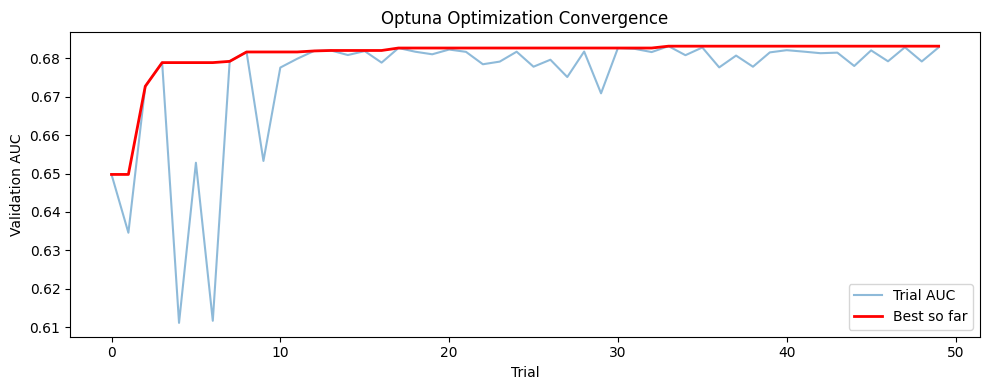

In [120]:
# Optuna Convergence Plot 
trial_values = [t.value for t in study_xgb.trials if t.value is not None]

plt.figure(figsize=(10, 4))
plt.plot(trial_values, alpha=0.5, label='Trial AUC')
plt.plot(pd.Series(trial_values).cummax(), color='red', linewidth=2, label='Best so far')
plt.xlabel('Trial')
plt.ylabel('Validation AUC')
plt.title('Optuna Optimization Convergence')
plt.legend()
plt.tight_layout()
plt.show()

In [121]:
# Train Best XGBoost

best_params = study_xgb.best_params.copy()
best_params.update({'scale_pos_weight': scale_pos, 'use_label_encoder': False,
                    'eval_metric': 'aucpr', 'random_state': 42, 'n_jobs': -1})

best_xgb = xgb.XGBClassifier(**best_params)
best_xgb.fit(
    X_train_sel, y_train,
    eval_set=[(X_val_sel, y_val)],
    verbose=100
)

best_xgb_val = best_xgb.predict_proba(X_val_sel)[:, 1]
print(f"\n[Best XGBoost] Val AUC-ROC: {roc_auc_score(y_val, best_xgb_val):.4f}")
print(f"[Best XGBoost] Val AUC-PR:  {average_precision_score(y_val, best_xgb_val):.4f}")

[0]	validation_0-aucpr:0.20823
[100]	validation_0-aucpr:0.22319
[200]	validation_0-aucpr:0.22658
[251]	validation_0-aucpr:0.22764

[Best XGBoost] Val AUC-ROC: 0.6831
[Best XGBoost] Val AUC-PR:  0.2282


# PROBABILITY CALIBRATION

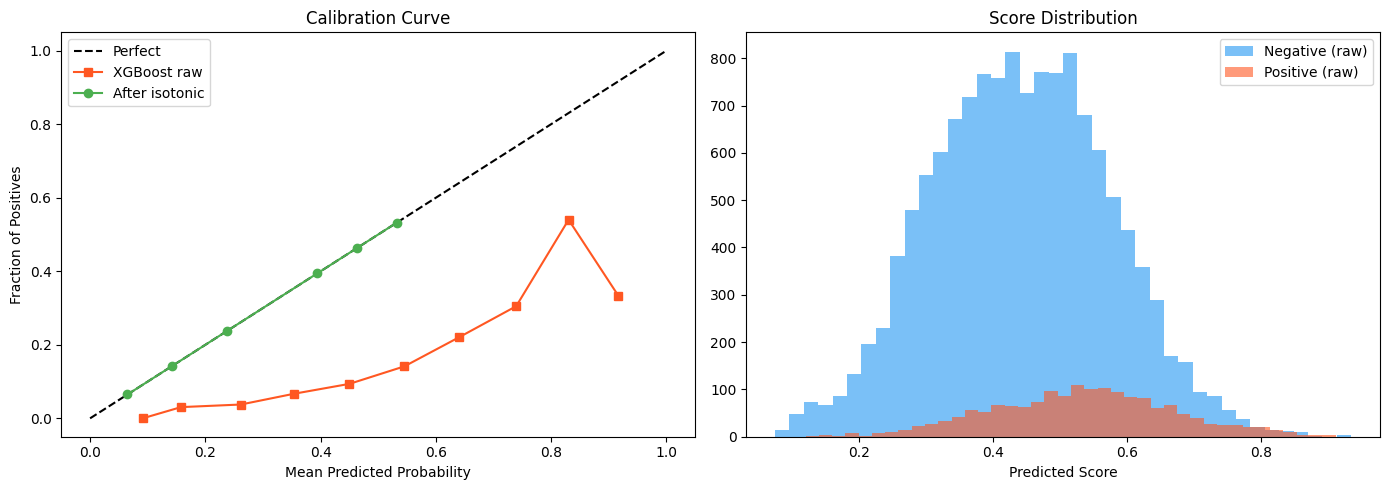

In [122]:
# Calibrate XGBoost

from sklearn.calibration import CalibratedClassifierCV, calibration_curve

calibrated_xgb = CalibratedClassifierCV(best_xgb, method='isotonic', cv='prefit')
calibrated_xgb.fit(X_val_sel, y_val)

cal_val_preds = calibrated_xgb.predict_proba(X_val_sel)[:, 1]

# Calibration Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before calibration
frac_pos_raw, mean_pred_raw = calibration_curve(y_val, best_xgb_val, n_bins=10)
frac_pos_cal, mean_pred_cal = calibration_curve(y_val, cal_val_preds, n_bins=10)

axes[0].plot([0,1],[0,1],'k--', label='Perfect')
axes[0].plot(mean_pred_raw, frac_pos_raw, 's-', label='XGBoost raw', color='#FF5722')
axes[0].plot(mean_pred_cal, frac_pos_cal, 'o-', label='After isotonic', color='#4CAF50')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Positives')
axes[0].set_title('Calibration Curve')
axes[0].legend()

# Score distribution before/after
axes[1].hist(best_xgb_val[y_val==0], bins=40, alpha=0.6, label='Negative (raw)', color='#2196F3')
axes[1].hist(best_xgb_val[y_val==1], bins=40, alpha=0.6, label='Positive (raw)', color='#FF5722')
axes[1].set_title('Score Distribution')
axes[1].set_xlabel('Predicted Score')
axes[1].legend()

plt.tight_layout()
plt.show()

In [123]:
# ECE computation
def compute_ece(y_true, y_pred, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = (y_pred >= bins[i]) & (y_pred < bins[i+1])
        if mask.sum() == 0:
            continue
        bin_acc = y_true[mask].mean()
        bin_conf = y_pred[mask].mean()
        ece += (mask.sum() / len(y_pred)) * abs(bin_acc - bin_conf)
    return ece

ece_raw = compute_ece(np.array(y_val), best_xgb_val)
ece_cal = compute_ece(np.array(y_val), cal_val_preds)
print(f"ECE before calibration: {ece_raw:.4f}")
print(f"ECE after  calibration: {ece_cal:.4f}")

ECE before calibration: 0.3390
ECE after  calibration: 0.0000


# RISK STRATIFICATION

In [124]:
# Use validation set score distribution to define thresholds
pos_scores = best_xgb_val[y_val == 1]

p25 = np.percentile(pos_scores, 25)
p50 = np.percentile(pos_scores, 50)
p75 = np.percentile(pos_scores, 75)

print(f"Risk Tier Thresholds:")
print(f"  Low    : score < {p25:.3f}")
print(f"  Medium : {p25:.3f} ≤ score < {p50:.3f}")
print(f"  High   : {p50:.3f} ≤ score < {p75:.3f}")
print(f"  Critical: score ≥ {p75:.3f}")

Risk Tier Thresholds:
  Low    : score < 0.439
  Medium : 0.439 ≤ score < 0.534
  High   : 0.534 ≤ score < 0.623
  Critical: score ≥ 0.623


In [125]:
def assign_risk_tier(score):
    if score < p25:   return 'Low'
    elif score < p50: return 'Medium'
    elif score < p75: return 'High'
    else:             return 'Critical'

val_tiers = pd.Series(best_xgb_val).apply(assign_risk_tier)
tier_readmission = pd.DataFrame({'tier': val_tiers.values, 'readmitted': y_val.values})

In [126]:
tier_summary = tier_readmission.groupby('tier').agg(
    count=('readmitted', 'count'),
    readmission_rate=('readmitted', 'mean')
).reindex(['Low', 'Medium', 'High', 'Critical'])
print("\nRisk Tier Summary:")
print(tier_summary)


Risk Tier Summary:
          count  readmission_rate
tier                             
Low        6992          0.059783
Medium     3787          0.110114
High       2570          0.162646
Critical   1536          0.272135


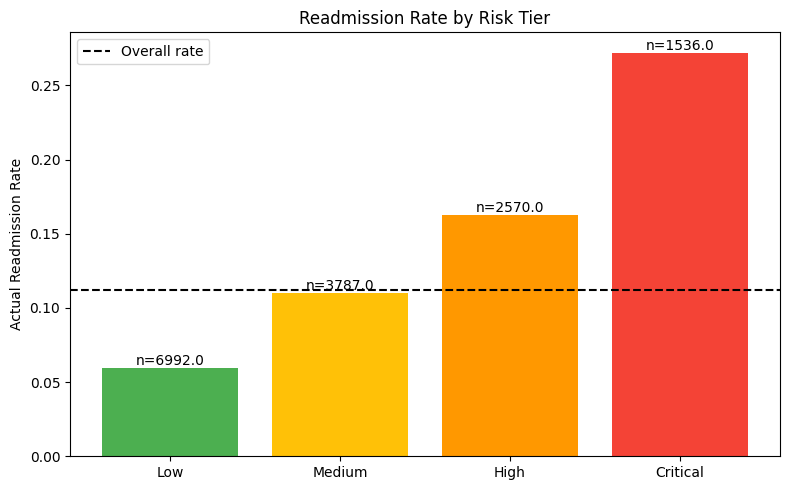

In [127]:
plt.figure(figsize=(8, 5))
colors = {'Low': '#4CAF50', 'Medium': '#FFC107', 'High': '#FF9800', 'Critical': '#F44336'}
bars = plt.bar(tier_summary.index,
               tier_summary['readmission_rate'],
               color=[colors[t] for t in tier_summary.index])
plt.axhline(y_val.mean(), linestyle='--', color='black', label='Overall rate')
plt.ylabel('Actual Readmission Rate')
plt.title('Readmission Rate by Risk Tier')
plt.legend()
for bar, (_, row) in zip(bars, tier_summary.iterrows()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f"n={row['count']}", ha='center', fontsize=10)
plt.tight_layout()
plt.show()

# MODEL EVALUATION

In [128]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)

In [129]:
# Final predictions on test set
test_probs = calibrated_xgb.predict_proba(X_test_sel)[:, 1]
test_preds = (test_probs >= 0.5).astype(int)

print("FINAL TEST SET EVALUATION")
print(f"AUC-ROC:     {roc_auc_score(y_test, test_probs):.4f}")
print(f"AUC-PR:      {average_precision_score(y_test, test_probs):.4f}")
print(f"ECE:         {compute_ece(np.array(y_test), test_probs):.4f}")
print(f"\nClassification Report (threshold=0.5):")
print(classification_report(y_test, test_preds))

FINAL TEST SET EVALUATION
AUC-ROC:     0.6809
AUC-PR:      0.2136
ECE:         0.0046

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     13249
           1       0.46      0.03      0.06      1675

    accuracy                           0.89     14924
   macro avg       0.68      0.51      0.50     14924
weighted avg       0.84      0.89      0.84     14924



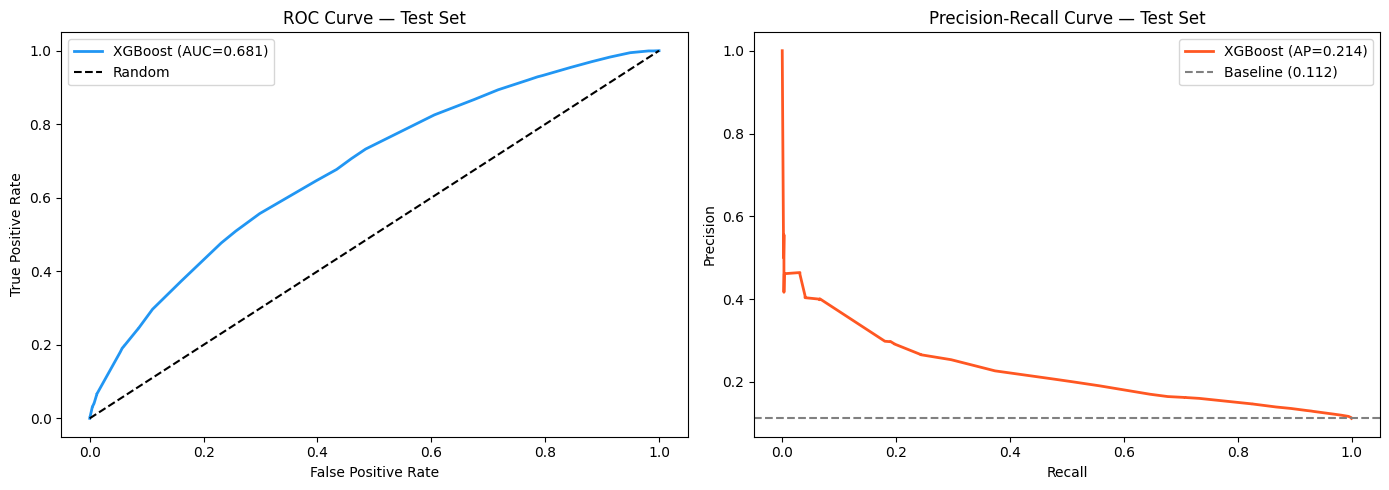

In [132]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, test_probs)
auc_roc = roc_auc_score(y_test, test_probs)
axes[0].plot(fpr, tpr, color='#2196F3', lw=2, label=f'XGBoost (AUC={auc_roc:.3f})')
axes[0].plot([0,1],[0,1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Test Set')
axes[0].legend()

# PR Curve
precision, recall, _ = precision_recall_curve(y_test, test_probs)
auc_pr = average_precision_score(y_test, test_probs)
axes[1].plot(recall, precision, color='#FF5722', lw=2, label=f'XGBoost (AP={auc_pr:.3f})')
axes[1].axhline(y_test.mean(), linestyle='--', color='gray', label=f'Baseline ({y_test.mean():.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — Test Set')
axes[1].legend()

plt.tight_layout()
plt.show()

In [133]:
# Clinical Utility Metrics

# Flag top 20% as high-risk — compute clinical metrics
threshold_20pct = np.percentile(test_probs, 80)
clinical_preds = (test_probs >= threshold_20pct).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, clinical_preds).ravel()
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0      # Precision (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0      # NPV
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
nnt = 1 / ppv if ppv > 0 else np.inf               # Number Needed to Treat

print(f"\nClinical Utility (Top 20% flagged as high-risk):")
print(f"  PPV (Precision):  {ppv:.3f}  — of those flagged, {ppv*100:.1f}% actually readmitted")
print(f"  NPV:              {npv:.3f}")
print(f"  Sensitivity:      {sensitivity:.3f}")
print(f"  NNT:              {nnt:.1f}  — treat {nnt:.0f} patients to prevent 1 readmission")


Clinical Utility (Top 20% flagged as high-risk):
  PPV (Precision):  0.207  — of those flagged, 20.7% actually readmitted
  NPV:              0.921
  Sensitivity:      0.477
  NNT:              4.8  — treat 5 patients to prevent 1 readmission


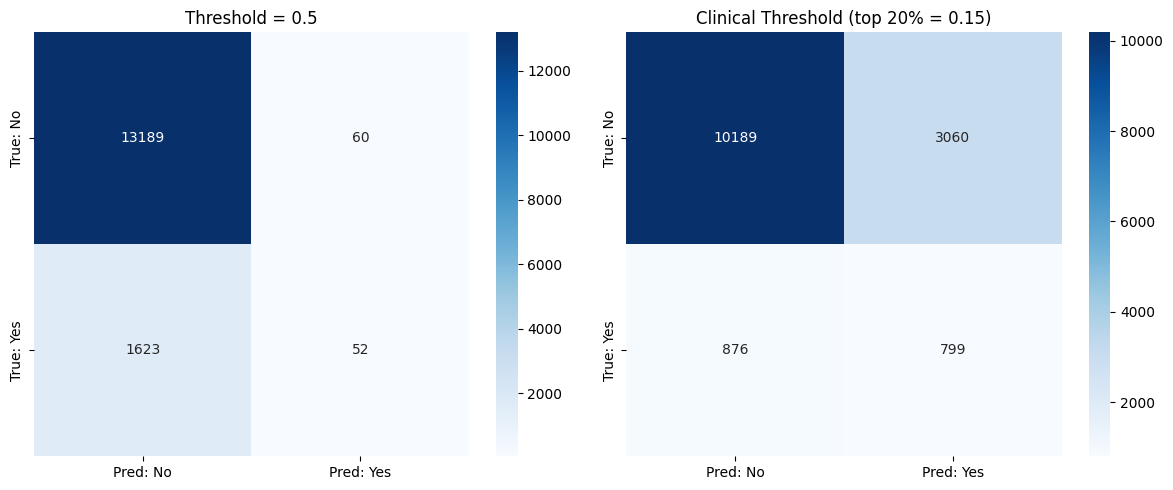

In [134]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, thresh, title in zip(
    axes,
    [0.5, threshold_20pct],
    ['Threshold = 0.5', f'Clinical Threshold (top 20% = {threshold_20pct:.2f})']
):
    preds = (test_probs >= thresh).astype(int)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred: No', 'Pred: Yes'],
                yticklabels=['True: No', 'True: Yes'])
    ax.set_title(title)

plt.tight_layout()
plt.show()

# SHAP EXPLANATIONS

PermutationExplainer explainer: 14925it [1:03:42,  3.90it/s]                           


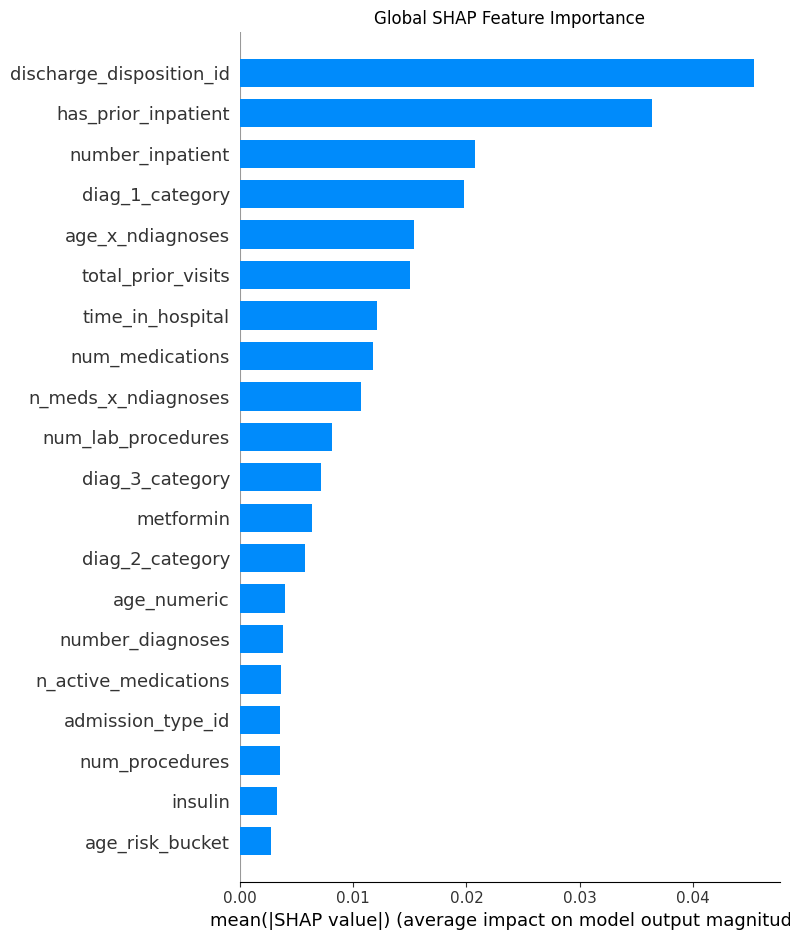

In [138]:
# Global SHAP

import shap
shap.initjs()

explainer = shap.Explainer(
    lambda x: best_xgb.predict_proba(x)[:, 1],
    X_test_sel,
    feature_names=final_features
)
shap_values = explainer(X_test_sel)

# Global feature importance
shap.summary_plot(shap_values, plot_type='bar', show=False)
plt.title('Global SHAP Feature Importance')
plt.tight_layout()
plt.show()

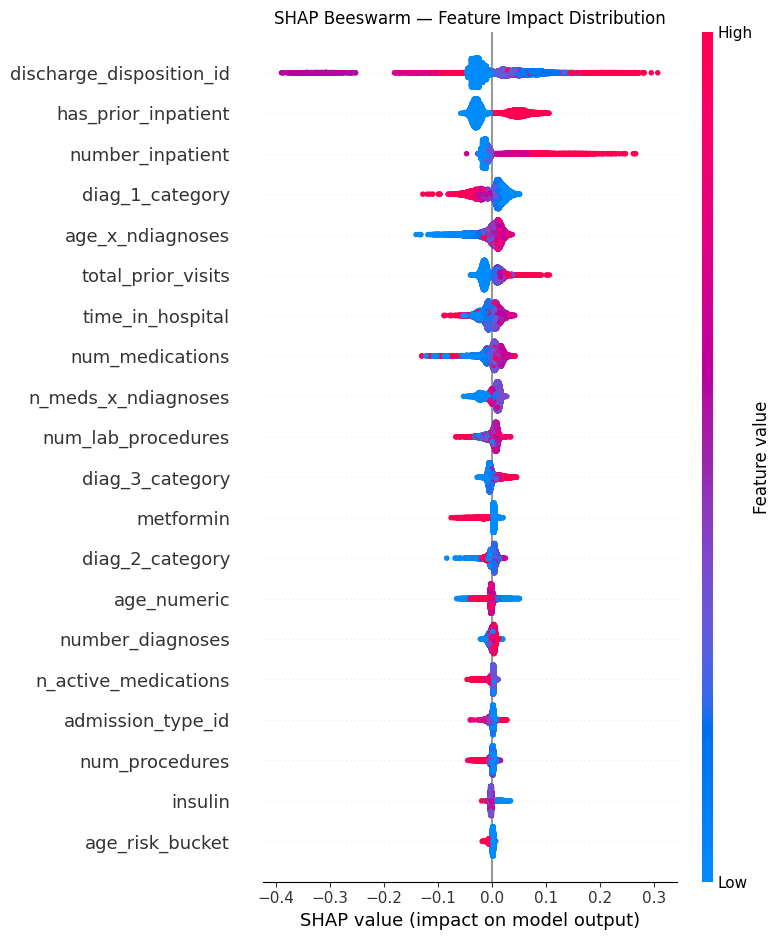

In [139]:
# SHAP Beeswarm

shap.summary_plot(shap_values, show=False)
plt.title('SHAP Beeswarm — Feature Impact Distribution')
plt.tight_layout()
plt.show()

Highest risk patient — predicted score: 0.556
Actual readmission:  1


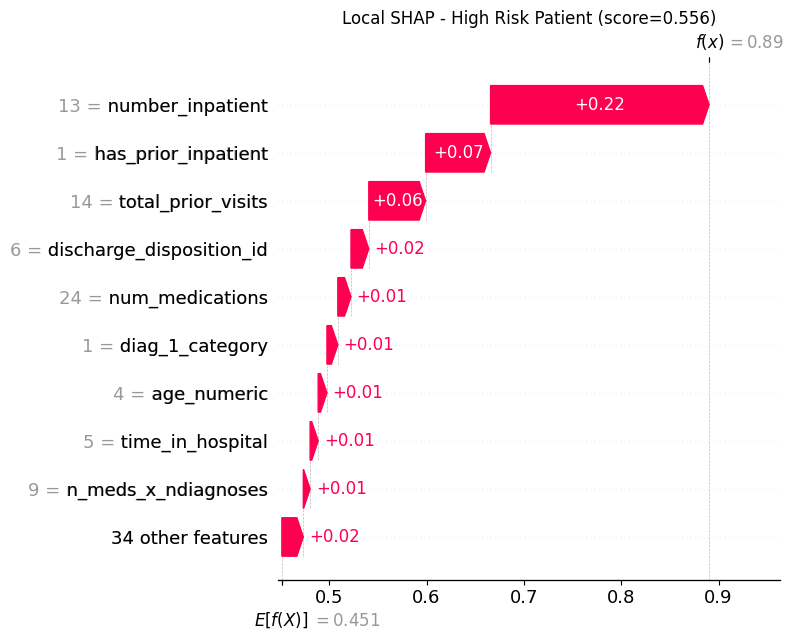

In [140]:
# Local SHAP — Single Patient

# Explain a high-risk patient
high_risk_idx = np.argmax(test_probs)
print(f"Highest risk patient — predicted score: {test_probs[high_risk_idx]:.3f}")
print(f"Actual readmission:  {y_test.iloc[high_risk_idx]}")

# Waterfall plot
shap.waterfall_plot(shap_values[high_risk_idx], show=False)
plt.title(f'Local SHAP - High Risk Patient (score={test_probs[high_risk_idx]:.3f})')
plt.tight_layout()
plt.show()


In [142]:
# SHAP Feature Impact Table

# Per-patient explanation as ranked list (what the API will return)
def get_shap_explanation(shap_vals, feature_vals, feature_names, top_k=5):
    shap_array = shap_vals.values if hasattr(shap_vals, 'values') else np.asarray(shap_vals)
    shap_array = np.asarray(shap_array).reshape(-1)

    explanation = []
    for name, shap_val, feat_val in zip(feature_names, shap_array, feature_vals):
        explanation.append({
            'feature': name,
            'value': round(float(feat_val), 3),
            'shap_impact': round(float(shap_val), 4),
            'direction': 'increases_risk' if shap_val > 0 else 'decreases_risk'
        })
    return sorted(explanation, key=lambda x: abs(x['shap_impact']), reverse=True)[:top_k]

sample_explanation = get_shap_explanation(
    shap_values[high_risk_idx],
    X_test_sel[high_risk_idx],
    final_features
)
print("\nTop 5 factors for high-risk patient:")
for e in sample_explanation:
    print(f"  {e['feature']}: value={e['value']}, impact={e['shap_impact']} ({e['direction']})")



Top 5 factors for high-risk patient:
  number_inpatient: value=13.0, impact=0.2244 (increases_risk)
  has_prior_inpatient: value=1.0, impact=0.0667 (increases_risk)
  total_prior_visits: value=14.0, impact=0.0584 (increases_risk)
  discharge_disposition_id: value=6.0, impact=0.0183 (increases_risk)
  num_medications: value=24.0, impact=0.0135 (increases_risk)
